**PROJECT:Dynamic Sensor-Based Fault Detection & Drift Monitoring System**
   **PHASE 1:Problem Framing, Data Ingestion & Stream Simulation
      #Section 1: Local Environment Setup & Data Extraction
      Objective: Programmatically extract the downloaded academic dataset from the local environment download path and verify its structure inside             our working repository directory.

      Data Source: UCI Machine Learning Repository (AI4I 2020 Predictive Maintenance Dataset)
      Target Output: Extraction of `ai4i2020.csv` into the current working directory.

In [11]:
import os
import zipfile
#Defining Path
download_path = r"C:\Users\samma\Downloads\ai4i+2020+predictive+maintenance+dataset.zip"
current_project_dir = os.getcwd()
# Extracting the zip archive
if os.path.exists(download_path):
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall(current_project_dir)
    print(f"Success! File extracted to: {current_project_dir}")
    print("Files in directory:", [f for f in os.listdir() if f.endswith('.csv')])
else:
    print(f" Error: Could not find the zip file at {download_path}")
    print("Please double check if the file extension is '.zip'.")

Success! File extracted to: C:\Sensor_Data
Files in directory: ['ai4i2020.csv', 'historical_baseline.csv', 'streaming_pool.csv']


Importing Necessary Libraries

In [26]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

 Reading Data From CSV File And Splitting It Into Two Separate Files

In [13]:
sensorData=pd.read_csv("ai4i2020.csv" , index_col='UDI')
pivot_index = 5000   #Splitting Index
historical_df = sensorData.iloc[:pivot_index]   #Saving the first half in a new dataframe
streaming_pool_df = sensorData.iloc[pivot_index:]  #Saving the other half into another new dataframe
historical_df.to_csv("historical_baseline.csv", index=False)  #Converting dataframe into a csv file
streaming_pool_df.to_csv("streaming_pool.csv", index=False)  #Converting dataframe into a csv file

**Exploratory Data Anaalysis**

In [14]:
sensorData.shape
sensorData.sample(10)
sensorData.describe()
sensorData.duplicated().sum()
sensorData.corr(numeric_only=True)
sensorData.info()
print(historical_df['Type'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  str    
 1   Type                     10000 non-null  str    
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
 8   TWF                      10000 non-null  int64  
 9   HDF                      10000 non-null  int64  
 10  PWF                      10000 non-null  int64  
 11  OSF                      10000 non-null  int64  
 12  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 1015.8 KB
<StringArray>
['M', 'L', 'H']
L

In [15]:
#Univariate Analysis

#Categorical Data
print(historical_df['TWF'].value_counts())
print(historical_df['HDF'].value_counts())
print(historical_df['PWF'].value_counts())
print(historical_df['OSF'].value_counts())
print(historical_df['RNF'].value_counts())
print(historical_df['Machine failure'].value_counts()) 

#Numerical Data
# 1. Boxplots
#sns.boxplot(data=historical_df, x='Air temperature [K]')
#sns.boxplot(data=historical_df, x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='Torque [Nm]')
#sns.boxplot(data=historical_df, x='Tool wear [min]')
# 2. KDE Distribution Plots
#sns.displot(data=historical_df, x='Air temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Process temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Torque [Nm]', kind='kde')
#sns.displot(data=historical_df, x='Tool wear [min]', kind='kde')
#sns.displot(data=historical_df, x='Rotational speed [rpm]', kind='kde')

TWF
0    4979
1      21
Name: count, dtype: int64
HDF
0    4885
1     115
Name: count, dtype: int64
PWF
0    4942
1      58
Name: count, dtype: int64
OSF
0    4949
1      51
Name: count, dtype: int64
RNF
0    4992
1       8
Name: count, dtype: int64
Machine failure
0    4765
1     235
Name: count, dtype: int64


In [16]:
#Bivariate Analysis

#Scatter Plots
#sns.scatterplot(data=historical_df, x='Air temperature [K]', y='Process temperature [K]')
#sns.scatterplot(data=historical_df, x='Rotational speed [rpm]', y='Torque [Nm]')
#Bar Plots
#sns.barplot(data=historical_df, x='Type', y='Torque [Nm]')
#sns.barplot(data=historical_df, x='Type', y='Rotational speed [rpm]')
#sns.barplot(data=historical_df, x='Type', y='Tool wear [min]')
#Box Plots
#sns.boxplot(data=historical_df[historical_df['TWF'] == 1],x='Tool wear [min]')
#sns.boxplot(data=historical_df, x='TWF', y='Tool wear [min]')
#sns.boxplot(data=historical_df[historical_df['PWF'] == 1],x='Torque [Nm]') 
#sns.boxplot(data=historical_df, x='PWF', y='Torque [Nm]')
#sns.boxplot(data=historical_df[historical_df['HDF'] == 1],x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='HDF', y='Process temperature [K]')
#Crosstabs
#type_vs_twf = pd.crosstab(historical_df['Type'], historical_df['TWF'],normalize='index') *100
#print(type_vs_twf)
#type_vs_twf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_osf = pd.crosstab(historical_df['Type'], historical_df['OSF'],normalize='index') *100
#print(type_vs_osf)
#type_vs_osf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_hdf = pd.crosstab(historical_df['Type'], historical_df['HDF'],normalize='index') *100
#print(type_vs_hdf)
#type_vs_hdf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_pwf = pd.crosstab(historical_df['Type'], historical_df['PWF'],normalize='index') *100
#print(type_vs_pwf)
#type_vs_pwf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_rnf =historical_df.groupby('Type')['RNF'].mean()*100  #this and above are both same commands just the difference is that above shows all three types and working and failure for each type but this shows three type and only failure for each type as when mean is used mean of 0,1 is 1. 
#print(type_vs_rnf)
#type_vs_rnf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])

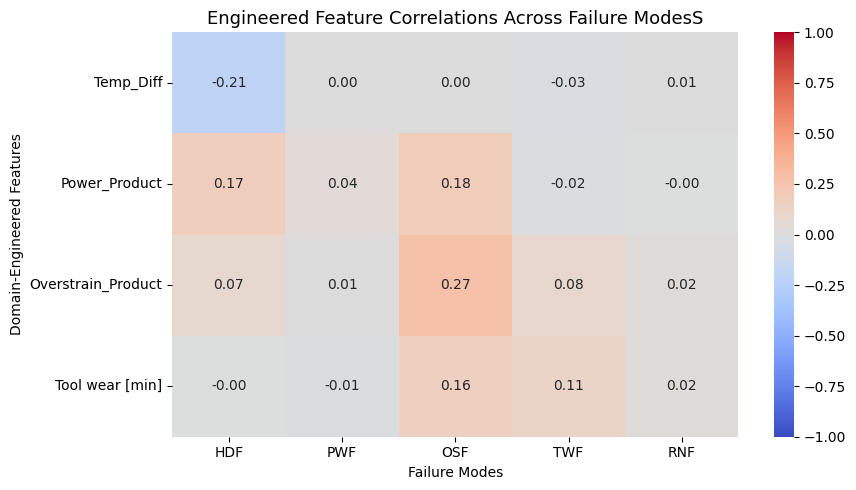

In [17]:
#Multivariate Analysis

#heatmap
#1
#plt.figure(figsize=(10, 8))
#numeric_df = historical_df.select_dtypes(include=['number'])  #Isolating the numerical column
#correlation_matrix = numeric_df.corr(method='pearson')   #Computing correlation 
#sns.heatmap(data=correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',vmin=-1, vmax=1)
#plt.title("Pearson Correlation Matrix (Checking for Multicollinearity)", fontsize=14)
#2
#sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
#failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
#cross_corr = historical_df[sensor_cols + failure_cols].corr().loc[sensor_cols, failure_cols]
#plt.figure(figsize=(8, 5))
#sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#plt.title("Sensor Correlations Across All Distinct Failure Modes")
#plt.show()
historical_df['Temp_Diff'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']
engineered_cols = ['Temp_Diff', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()
#pairplots
#a
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='TWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Tool Wear Failures (TWF)", y=1.02, fontsize=14)
#plt.show()
#b
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'PWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='PWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Power Wear Failures (PWF)", y=1.02, fontsize=14)
#plt.show()
#c
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'OSF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='OSF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Over Strain Failures (OSF)", y=1.02, fontsize=14)
#plt.show()
#3 Variable scatter plot
#plt.figure(figsize=(9, 6))
#sns.scatterplot(data=historical_df,x='Air temperature [K]',y='Process temperature [K]',hue='HDF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
#plt.title("Operational Overload Boundaries: Air Temperature vs. Process Temperature", fontsize=13)
#plt.xlabel("Air Temperature [K]")
#plt.ylabel("Process Temperature [K]")
#plt.grid(True, linestyle='--', alpha=0.5)
#plt.show()


**Feature Engineering**

In [18]:
#Feature Construction
historical_df['Temperature_Difference'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']

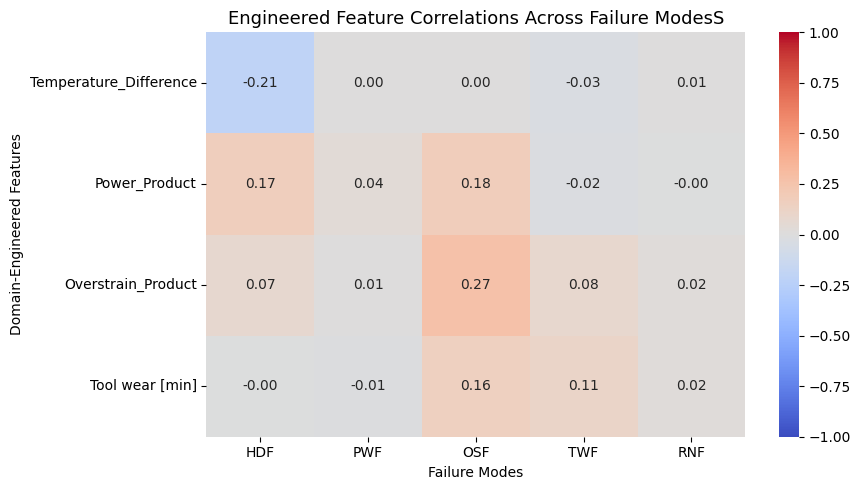

In [19]:
#Heatmap
engineered_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import  StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
from sklearn.decomposition import PCA
set_config(transform_output="pandas")

class IQROutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            q1 = X_df[col].quantile(0.25)
            q3 = X_df[col].quantile(0.75)
            iqr = q3 - q1
            self.lower_bounds_[col] = q1 - (self.factor * iqr)
            self.upper_bounds_[col] = q3 + (self.factor * iqr)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_:
                X_df[col] = np.clip(
                    X_df[col], 
                    self.lower_bounds_[col], 
                    self.upper_bounds_[col]
                )
        return X_df
X = historical_df.drop(columns=['Machine failure', 'Product ID'], errors='ignore')
Y = historical_df['Machine failure']
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,stratify=Y,random_state=0) #stratify is used to ensure that failures are evenly divided
ordinal_cols = ['Type']
numeric_cols = ['Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'Temperature_Difference','Power_Product','Overstrain_Product']

# A. Sub-pipeline for Numeric Columns (Impute -> Clip Outliers -> Scale)
numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),           
    ('outlier_clipper', IQROutlierClipper(factor=1.5)), 
    ('scaler', StandardScaler())                     
])

# B. Sub-pipeline for Categorical/Ordinal Columns
ordinal_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[['L', 'M', 'H']]))
])

# C. ColumnTransformer combining both branches
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('ord', ordinal_pipeline, ordinal_cols)],
        remainder='drop'
)

# D. Final Immutable Phase
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.90))
])

Model Training And Prediction 

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# ==============================================================================
# MODEL 1: Logistic Regression (With PCA)
# ==============================================================================
logistic_pipeline = Pipeline([
               ('feat_engineering' , pipe),
               ('Logistic', LogisticRegression(max_iter=10000, class_weight='balanced'))
])

logistic_pipeline.fit(x_train,y_train)
logistic_prediction=logistic_pipeline.predict(x_test)

logistic_accuracy=accuracy_score(y_test,logistic_prediction)
print(f"Accuracy: {logistic_accuracy:.4f}\n")
print(classification_report(y_test, logistic_prediction))
print("Confusion Matrix:")
print(confusion_matrix(y_test, logistic_prediction))

# ==============================================================================
#  MODEL 1: Random Forest (Without PCA)
# ==============================================================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced', 
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(x_train, y_train)
rf_preds = rf_pipeline.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_preds)
print(f"Accuracy: {rf_accuracy:.4f}\n")
print(classification_report(y_test, rf_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

# ==============================================================================
# ADVANCED MODEL 2: Gradient Boosting (Without PCA)
# ==============================================================================

hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        class_weight='balanced',
        max_iter=200,
        learning_rate=0.05,
        random_state=42
    ))
])

hgb_pipeline.fit(x_train, y_train)
hgb_preds = hgb_pipeline.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, hgb_preds):.4f}\n")
print(classification_report(y_test, hgb_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, hgb_preds))

Accuracy: 0.7320

              precision    recall  f1-score   support

           0       0.98      0.73      0.84      1430
           1       0.12      0.77      0.21        70

    accuracy                           0.73      1500
   macro avg       0.55      0.75      0.53      1500
weighted avg       0.94      0.73      0.81      1500

Confusion Matrix:
[[1044  386]
 [  16   54]]
Accuracy: 0.9833

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1430
           1       0.88      0.74      0.81        70

    accuracy                           0.98      1500
   macro avg       0.93      0.87      0.90      1500
weighted avg       0.98      0.98      0.98      1500

Confusion Matrix:
[[1423    7]
 [  18   52]]
Accuracy: 0.9807

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1430
           1       0.75      0.87      0.81        70

    accuracy                          